# Demo: Mapping Luhman 16B with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf Luhman 16B to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started!

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from spectralmap.utilities import bin_flux_by_theta
from spectralmap.plotting import COLOR_LIST, PAPER_FIGURES_DIR

## 1. Load Data
We load the NIRSpec lightcurve files. Each file corresponds to a specific rotation phase (angle). We will read them in, sort them by phase, and normalize the flux.

In [20]:
import numpy as np
from spectralmap.utilities import bin_flux_by_theta

# 1. Load the data files
data_file = "data/Luhman16b_NIRSpec_2023.npz"
theta = np.load(data_file)["theta"]
wl = np.load(data_file)["wl"]
flux_raw = np.load(data_file)["flux_raw"]

amplitudes = np.nanmean(flux_raw, axis=1)
flux = (flux_raw.T / amplitudes).T

theta, flux, flux_err, counts = bin_flux_by_theta(theta, flux, n_bins=64, flux_err=None)

## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object. We must specify the inclination of the object (here assumed to be 80 degrees).

In [22]:
from spectralmap.mapping import LightCurveData, make_map
data = LightCurveData(theta=theta, flux=flux, flux_err=None, inc=90)

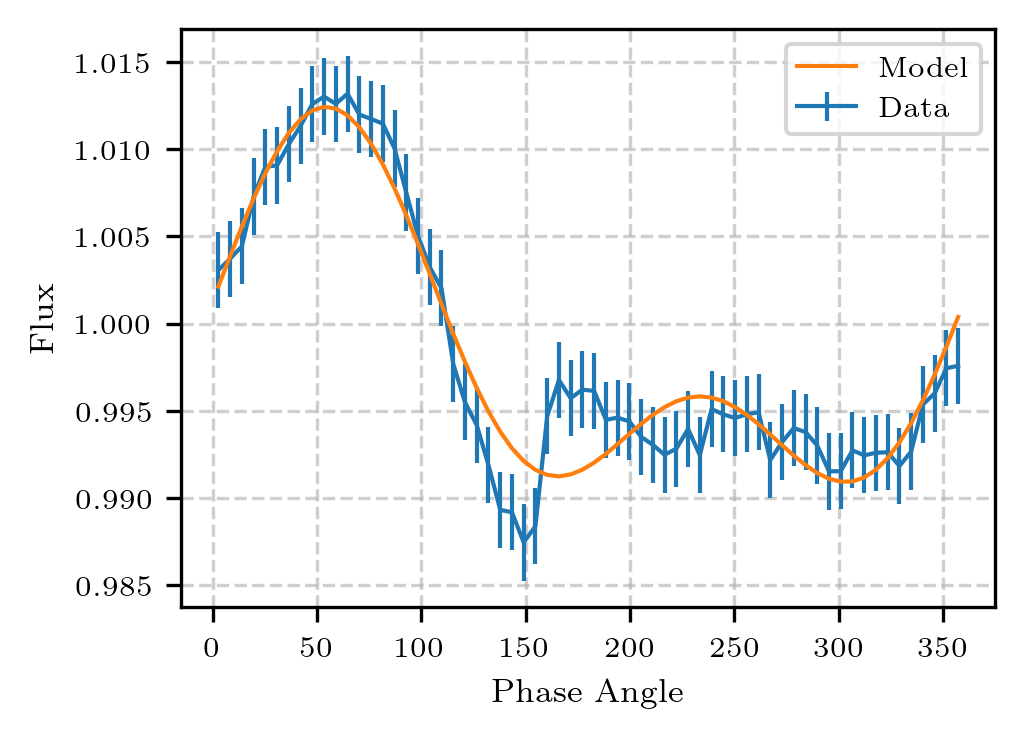

In [23]:
wl_test = 4.5
i_wl = np.argmin(np.abs(wl - wl_test))
map = make_map(mode='rotational', map_res=30, ydeg=2, inc=90)
map.solve_posterior(data.flux[i_wl], None, data.theta, verbose=False)
map.plot_lightcurve()

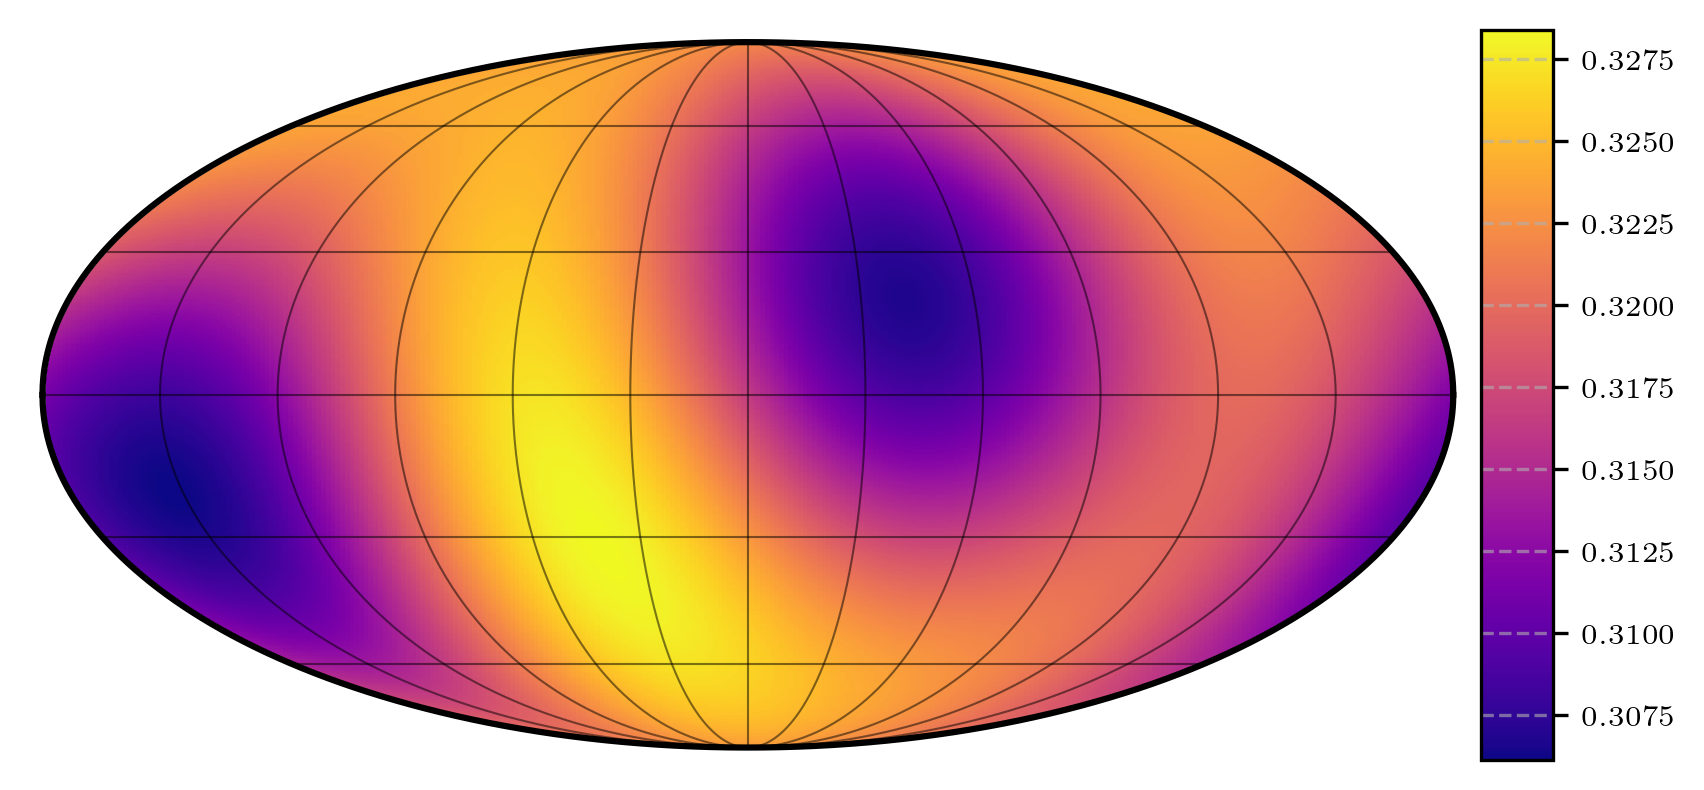

In [7]:
_ = map.draw(plot=True, projection="moll", grid=True, colorbar=True, n_samples=1)

### Find Optimal Map Complexity
We now solve for the maps. Since we don't know the complexity of the surface beforehand, we test spherical harmonic degrees ranging from `ydeg=2` to `ydeg=10`. The algorithm will automatically select the degree that best fits the data without overfitting (using the Bayesian Information Criterion).

In [24]:
from spectralmap.mapping import make_maps
maps = make_maps(mode='rotational', map_res=30, ydegs=np.arange(2, 10))

In [25]:
# Solve for the best spherical harmonic degree (ydeg) for each wavelength
# This optimizes the model complexity (model evidence) to avoid overfitting
w_all, I_all_wl, I_cov_all_wl = maps.marginalized_maps(data)

ydeg: 100%|██████████| 4/4 [00:03<00:00,  1.01it/s, wl 334/334]


lambda=None: Best-evidence wavelength counts by ydeg: ydeg=2: 12, ydeg=4: 273, ydeg=6: 49, ydeg=8: 0


## 3. Visualize the Maps
Let's take a look at the recovered maps for a few wavelengths to see how the surface features change.

In [26]:
# for i, ydeg in enumerate(ydeg_best[:10]):
#     if ydeg <= 5:
#         plt.figure()
#         plt.imshow(I_all_wl[i].reshape((30, 30)), origin='lower')
#         plt.title(f"Wavelength {wl[i]: .2f}: best ydeg = {ydeg}")

## 4. Spectral Extraction
We convert the retrieved intensity maps ($I$) back into physical flux units ($F$) and calculate the associated variances. This gives us the spatially-resolved spectra.

In [27]:
F_all_wl = I_all_wl * amplitudes[:, None] *np.pi
F_cov_all_wl = I_cov_all_wl * (np.pi * amplitudes[:, None, None])**2
F_var_all_wl = np.diagonal(F_cov_all_wl, axis1=1, axis2=2)

In [28]:
from spectralmap.mapping import expand_moll_values
F_all_wl_grid = expand_moll_values(F_all_wl, maps.moll_mask_flat)
F_var_all_wl_grid = expand_moll_values(F_var_all_wl, maps.moll_mask_flat)

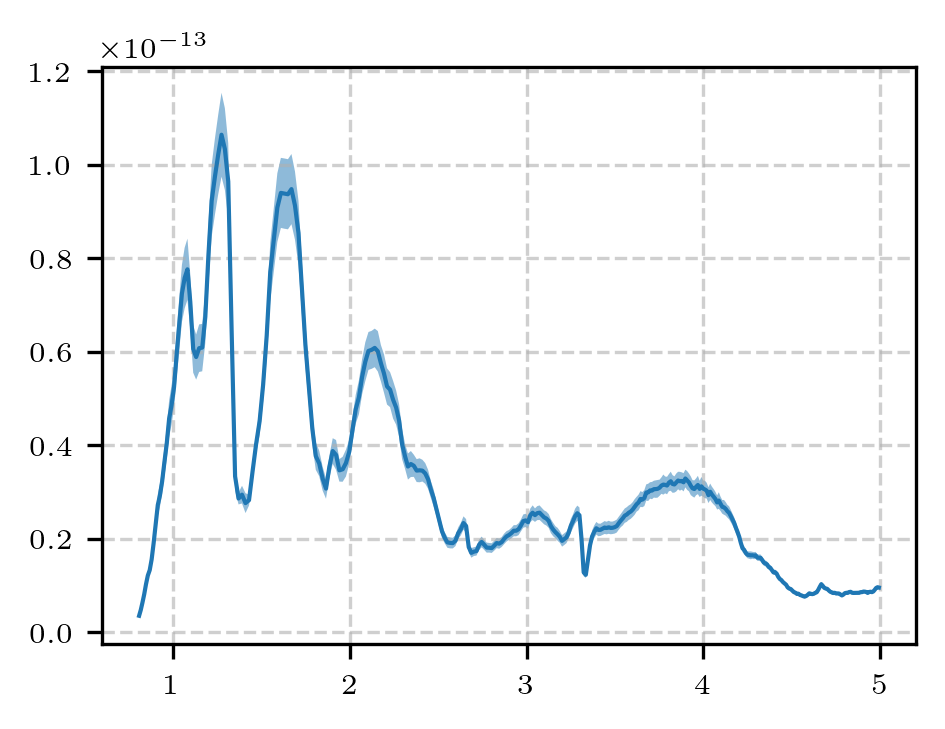

In [29]:
import matplotlib.pyplot as plt
i_grid = -1
plt.plot(wl[:], F_all_wl[:, i_grid])
plt.fill_between(wl[:], F_all_wl[:, i_grid] - np.sqrt(F_var_all_wl[:, i_grid]), F_all_wl[:, i_grid] + np.sqrt(F_var_all_wl[:, i_grid]), alpha=0.5)

## 5. Clustering and Regional Identification
To make sense of the map, we group pixels that show similar spectral behavior using a clustering algorithm. This helps us identify distinct "regions" or features on the object's surface.

-1 600
0 100
1 100
2 100


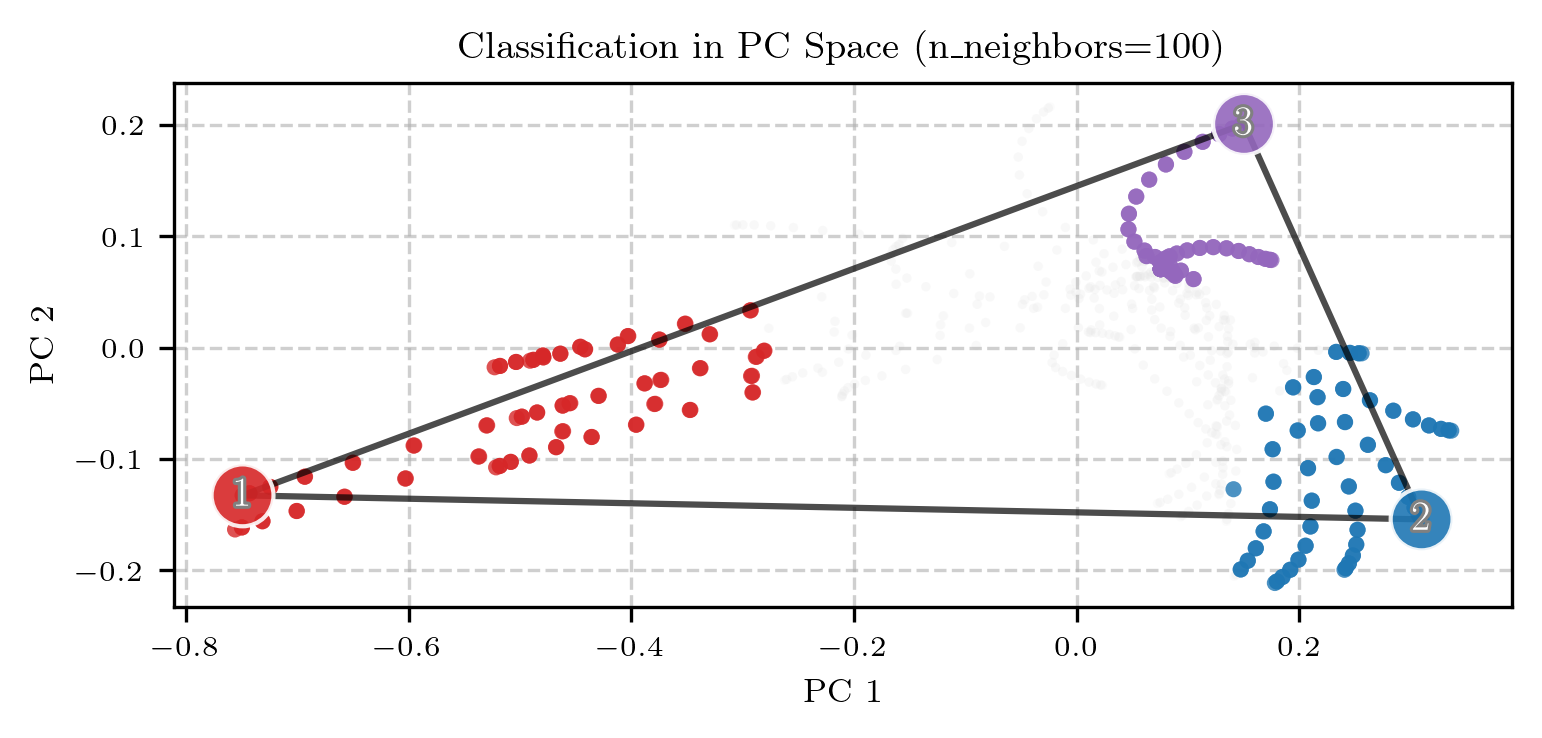

In [40]:
from spectralmap.cluster import find_clusters
F_regionals, F_regional_errs, labels = find_clusters(F_all_wl, F_cov_all_wl, n_neighbors=100, n_corners=3)
N = len(F_regionals)

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit_transform(np.log10(F_all_wl).T)
pca.explained_variance_ratio_

array([0.83728921, 0.13407612])

## 6. Results
Finally, we visualize the identified clusters on the map and plot the mean spectrum for each region.

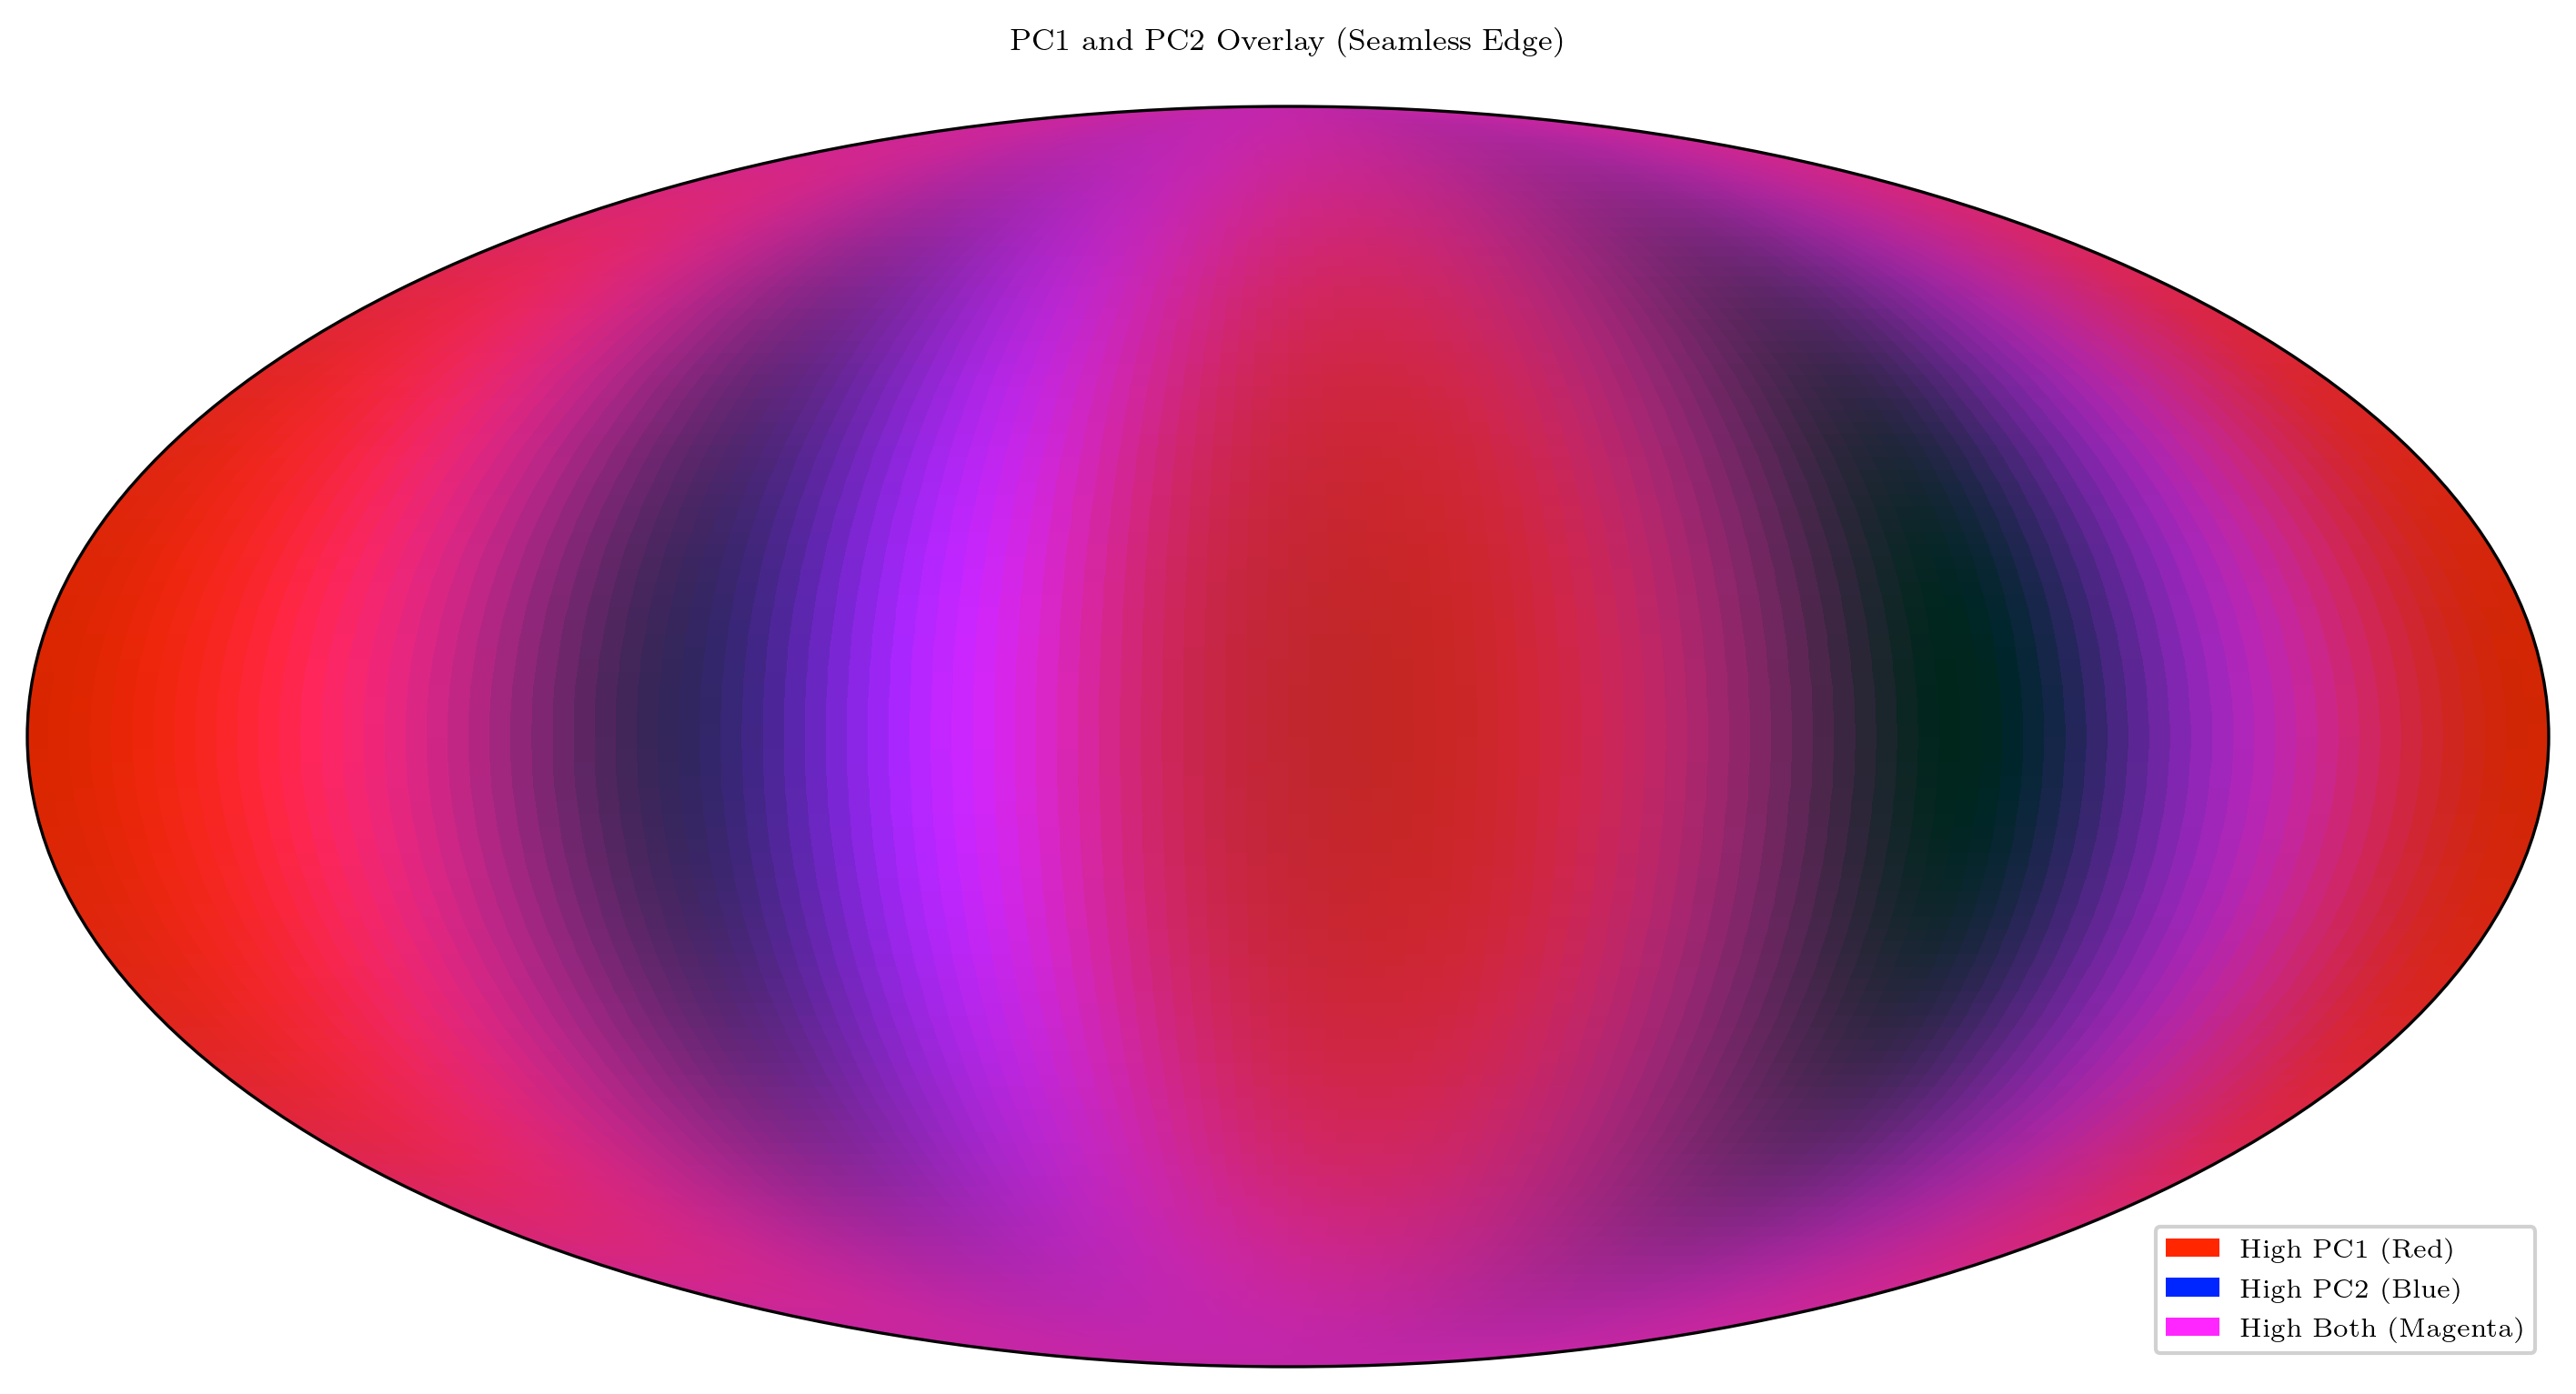

In [42]:
from sklearn.decomposition import PCA
from spectralmap.utilities import expand_moll_values
from spectralmap.plotting import plot_mollweide_rgb
pca = PCA(n_components=2)
PCs = pca.fit_transform(np.log(F_all_wl).T)  # shape: (n_wavelengths, 2)
pc1_scores = PCs[:, 0]
pc2_scores = PCs[:, 1]

mask_2d = maps.moll_mask
fig, ax = plot_mollweide_rgb(pc1_scores, pc2_scores, mask_2d, upsample=4)
plt.show()

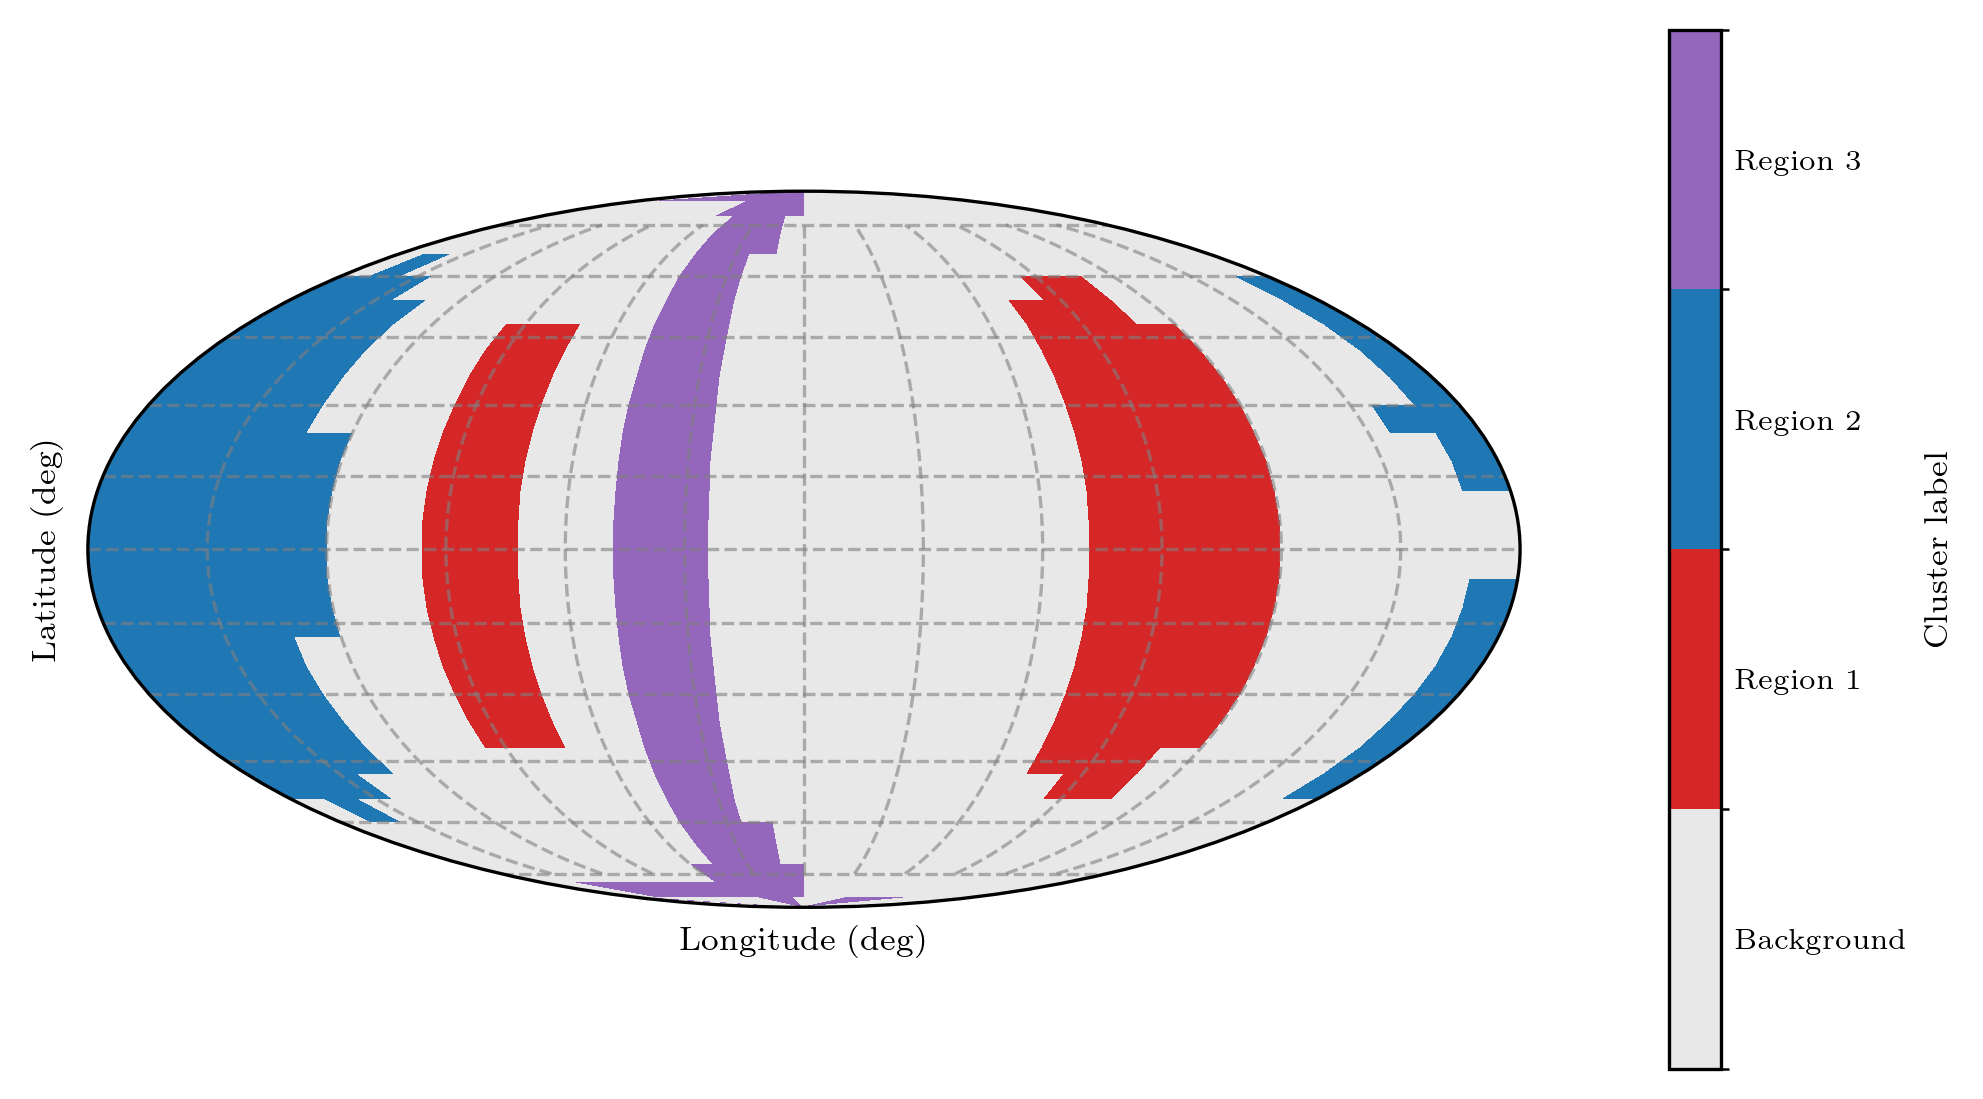

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from spectralmap.plotting import plot_mollweide_labels
from matplotlib import colors as mcolors


color_list = COLOR_LIST[:N]
cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]
cmap = mcolors.ListedColormap(color_list)

fig, ax, pcm, cb = plot_mollweide_labels(
    labels_masked=labels,      # should be ints 0..N-1 on masked pixels
    moll_mask=maps.moll_mask,
    map_res=map.map_res,
    cmap=cmap,
    names=cluster_names
)

output_path = PAPER_FIGURES_DIR + "S0136_recovered_regions.pdf"


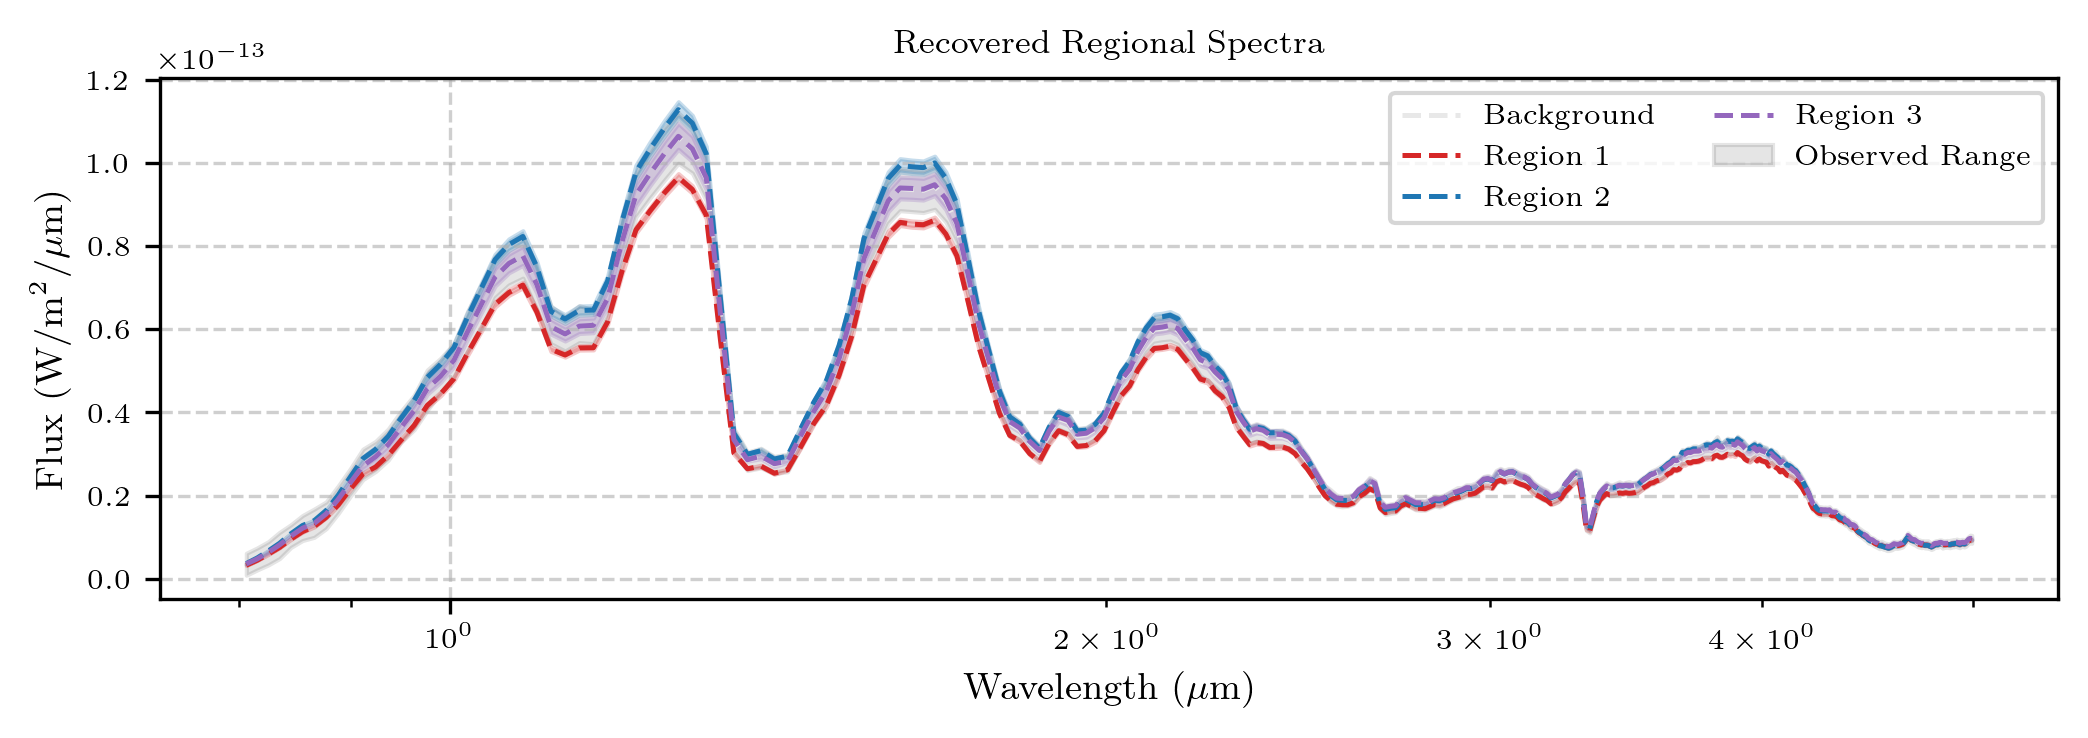

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr

fig, ax = plt.subplots(figsize=(7, 2.5))

color_list = COLOR_LIST[:N]

# Plot the recovered spectra for each region
for i in range(N):
    mean_flux = F_regionals[i]
    error_flux = F_regional_errs[i] # Fixed variable name
    color = color_list[i]
    label = cluster_names[i]
    
    ax.plot(wl, mean_flux, label=f"{label}", color=color, linewidth=1.2, linestyle='--')
    ax.fill_between(wl, 
                    mean_flux - error_flux, 
                    mean_flux + error_flux, 
                    alpha=0.25, color=color)
    
# Overlay the range of the observed time-series variability
time_series = np.sort(flux_raw.T, axis=0)
ax.fill_between(wl, time_series[0, :],
            time_series[-1, :], color='black', alpha=0.10, zorder=0, label="Observed Range")

# Formatting
ax.set_xlabel(r"Wavelength ($\mu$m)", fontsize=9)
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=9)
ax.set_title("Recovered Regional Spectra")
ax.legend(loc='upper right', ncol=2)
ax.set_xscale("log")
plt.tight_layout()
# output_path = PAPER_FIGURES_DIR / "S0136_recovered_spectra.pdf"
# plt.savefig(output_path, dpi=600, bbox_inches='tight')

plt.show()